# HelpHerInvest: Modeling Update (Weeks 6–9)

**Chris Toomey, Jenice An, and Tongyu Guo**  
ADAN 8888 - Applied Analytics Project - Spring 2026

This notebook is a short presentation-style update on our modeling progress from **Week 6 through Week 9**. It focuses on how our prediction models evolved, what we learned from each stage, and how we selected our current winning direction.


## Project Goal

**HelpHerInvest** is a machine learning-based investment recommendation system that aligns user interests and risk preferences with benchmark stock evaluation.

At a high level, our system has two parts:

1. **Interest-based filtering** to narrow the stock universe based on what a user is interested in
2. **Performance prediction** to estimate which stocks are more likely to outperform the S&P 500

This presentation focuses on the **performance prediction stage**, where we compared several modeling approaches over Weeks 6–9.


## Modeling Roadmap

We approached the supervised modeling portion of the project in stages:

- **Week 6:** establish a simple, interpretable baseline with logistic regression
- **Week 7:** test a more flexible tree-based model with LightGBM
- **Week 8:** explore an LLM-based workflow as an experimental direction
- **Week 9:** compare all model families and test neural network variations

The goal was not just to find the single highest score, but to understand how model complexity, generalization, and practicality changed across approaches.


## Week 6: Baseline Model

For our first modeling approach, we selected logistic regression since our objective was to classify stocks based on their forward excess return relative to the S&P 500. This made the task a supervised classification problem rather than a continuous forecasting task.

We started here because logistic regression gave us a clear baseline and helped us evaluate whether our engineered financial indicators had predictive value before moving to more complex methods.

Our Week 6 winning variation was **Weighted Logistic Regression**, which gave us the strongest balance among the logistic models.


### Week 6 Key Result

| Week 6 Results | Validation Macro F1 |
|---|---:|
| Weighted Logistic Regression    | 0.5008 |
| Elastic Net Logistic Regression | 0.4501 |
| L1 Logistic Regression          | 0.4500 |

**Takeaway:** The Weighted Logistic Regression model was the winner. Overall, the logistic regression models gave us a useful benchmark, but performance was still modest and suggested that more flexible models might capture additional signal.


## Week 7: Second Modeling Approach — LightGBM

For our second modeling approach, we selected a **Light Gradient-Boosting Machine (LightGBM / LGBM)** classifier. This model is similar to random forests, but it builds trees sequentially and attempts to correct errors from previous trees. We chose it because it is better suited for capturing more complex, non-linear relationships in the technical dataset.

We tested three LightGBM variations:

- **LGBM Model 1:** baseline configuration
- **LGBM Model 2:** balanced class weights
- **LGBM Model 3:** lightweight configuration

Week 7 was important because it was our first attempt to move beyond a simple linear baseline and test whether a more adaptive model could improve stock classification performance.


### Week 7 Validation Results

| Model | Validation Macro F1 |
|---|---:|
| LightGBM Model 1 | 0.5063 |
| LightGBM Model 2 | 0.5088 |
| LightGBM Model 3 | 0.4991 |
| Week 6 Weighted Logistic Regression | 0.5008 |

LightGBM Model 2 produced the best validation F1 score by a slight margin. The improvement over logistic regression was not dramatic, but it suggested that a tree-based model could capture some additional structure in the data.


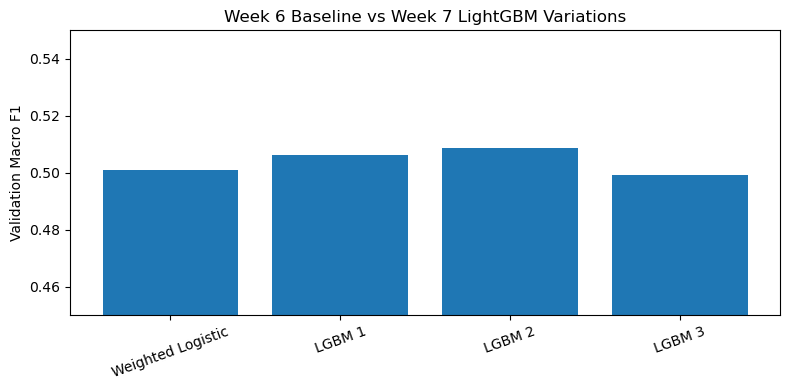

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

week7_compare = pd.DataFrame({
    "Model": ["Weighted Logistic", "LGBM 1", "LGBM 2", "LGBM 3"],
    "Validation Macro F1": [0.5008, 0.5063, 0.5088, 0.4991]
})

plt.figure(figsize=(8,4))
plt.ylim(0.45, 0.55)  
plt.bar(week7_compare["Model"], week7_compare["Validation Macro F1"])
plt.title("Week 6 Baseline vs Week 7 LightGBM Variations")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Week 7 Takeaway

The main takeaway from Week 7 was that **LightGBM slightly improved performance**, but not by a wide margin. This told us two things: first, there was likely some non-linear signal in the data; second, the dataset itself still had limitations that prevented a major jump in results.


## Week 8: Exploratory LLM Workflow

In Week 8, we tested an **LLM-based file reasoning workflow** as a more experimental modeling direction. The model was given a stock symbol reference dataset and a company/fundamental dataset. It then had to interpret a user's investing theme, select exactly 20 relevant stocks, rank them, explain the basis for the ranking, and clearly state data limitations.

This approach made sense for the broader HelpHerInvest system because the task was not only about ranking stocks, but also about understanding natural language, retrieving relevant symbols, combining information across files, and communicating limitations clearly.

However, we treated this as an exploratory workflow rather than our final modeling direction.


### Week 8 Summary Results

| Variation | Model | Validation Overall Score |
|---|---|---:|
| V1_baseline_mini | gpt-5-mini | 0.0 |
| V2_strict_mini | gpt-5-mini | 0.0 |
| V3_strict_gpt54 | gpt-5.4 | 1.0 |

The Week 8 results showed a sharp difference between the smaller and stronger LLM configurations. Prompt structure alone was not enough; model capability mattered much more for this task.


### Week 8 Takeaway

The LLM workflow was useful because it matched the natural-language side of our project, but it was not the most practical path forward for the supervised prediction stage. We also ran into workflow and reproducibility issues around API usage and key management, so we decided not to continue with this as our main modeling direction.

Instead, we treated Week 8 as a valuable experiment that helped us think more clearly about where LLMs fit best in the overall system.


## Week 9: Final Modeling Approach — Neural Networks

For the third and final modeling approach, we implemented neural network models using TensorFlow. We felt that variations of neural networks could be helpful in capturing non-linear relationships between our independent variables and the dependent variable, especially since the technical features in the dataset contain noisy and overlapping relationships.

We tested three neural network variations:

- **Baseline Neural Network**
- **Regularized Neural Network**
- **Regularized Deep Neural Network**

At this stage, the goal was to see whether a neural architecture could outperform both logistic regression and LightGBM once we introduced a more flexible model class.


### Validation F1 Across All 9 Models

According to our Week 9 comparison, the validation F1 scores were:

| Model | Validation F1 |
|---|---:|
| LightGBM Model 2 | 0.5088 |
| LightGBM Model 1 | 0.5063 |
| Baseline NN Model | 0.5047 |
| Weighted Logistic Regression | 0.5008 |
| LightGBM Model 3 | 0.4991 |
| Regularized Deep NN Model | 0.4947 |
| Regularized NN Model | 0.4866 |
| Elastic Net Logistic Regression | 0.4501 |
| Logistic Regression | 0.4500 |

Based on validation F1 alone, **LightGBM Model 2** remained the strongest model.


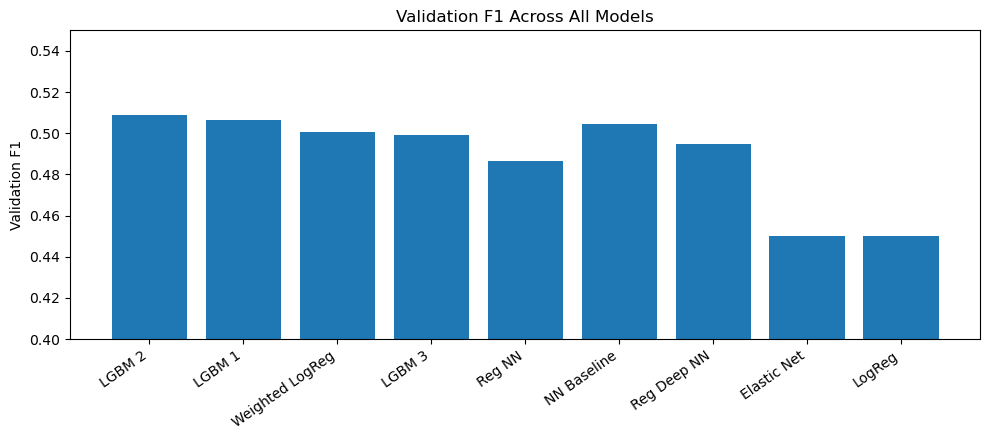

In [5]:
all_models = pd.DataFrame({
    "Model": [
        "LGBM 2", "LGBM 1", "Weighted LogReg", "LGBM 3",
        "Reg NN", "NN Baseline", "Reg Deep NN", "Elastic Net", "LogReg"
    ],
    "Validation F1": [0.5088, 0.5063, 0.5008, 0.4991, 0.4866, 0.5047, 0.4947, 0.4501, 0.4500]
})

plt.figure(figsize=(10,4.5))
plt.ylim(0.4, 0.55)  
plt.bar(all_models["Model"], all_models["Validation F1"])
plt.title("Validation F1 Across All Models")
plt.ylabel("Validation F1")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Bias-Variance Interpretation

Our Week 9 report suggested that the logistic regression models showed relatively high validation and training error, which points to bias because they failed to capture more complex relationships in the data. At the same time, the neural network models did not improve validation performance, even though they were the most complex models we tested.

This suggests that simply increasing model complexity did not solve the problem. The LightGBM models appeared to reduce bias without introducing major instability, which helps explain why they performed best overall on validation.


## Final Model Selection

Our strongest performing model based on the **validation F1 score** was **LightGBM Model 2**, using balanced class weights. The validation F1 for this model was **0.5088**, and the report notes that its test performance was slightly better as well, which suggests the model generalized reasonably well under the dataset constraints.

One interesting result from Week 9 is that, when we also checked test-set results across models, the **baseline neural network slightly outperformed LightGBM Model 2 on the test set**. Even so, LightGBM Model 2 remained our selected model because it was the strongest and most consistent choice based on the validation-driven model selection process.


### **LightGBM Model 2 - Test Set:**

#### Classification Report

| Class        | Precision | Recall | F1-Score | Support |
|--------------|----------:|-------:|---------:|--------:|
| 0            | 0.55      | 0.53   | 0.54     | 25,892  |
| 1            | 0.48      | 0.50   | 0.49     | 22,601  |
| **Accuracy** |           |        | **0.52** | 48,493  |
| Macro Avg    | 0.52      | 0.52   | 0.52     | 48,493  |
| Weighted Avg | 0.52      | 0.52   | 0.52     | 48,493  |

#### Additional Metrics

| Metric  | Value  |
|---------|-------:|
| F1 Score | 0.5155 |
| ROC-AUC  | 0.5215 |

## Main Takeaways

Across Weeks 6–9, our modeling process showed a fairly consistent pattern:

- Logistic regression gave us a clear baseline
- LightGBM provided the best validation performance overall
- The LLM workflow was a useful exploratory experiment, but not the best fit for this stage
- Neural networks were promising in theory, but they did not surpass LightGBM on validation

At this point, our strongest overall conclusion is that **LightGBM Model 2** gives us the best balance of performance, generalization, and practicality for the supervised prediction stage of HelpHerInvest.


## Current Project Position

Going forward, the main opportunity is not necessarily choosing an even more complex model, but improving the quality of the signal in the dataset. Our reports suggest that multicollinearity and overlapping feature construction may be limiting performance across model families. Because of that, additional feature engineering and data improvement may matter more than further model complexity alone.
